# VGParadox JP Top Decks — Automated Tierlist
Scrapes [vg-paradox.com/subpage/TopDecksJP.html](https://vg-paradox.com/subpage/TopDecksJP.html), scores each deck, and renders a tierlist.

## 1. Install dependencies

In [1]:
# Run once — installs Playwright and its Chromium browser
import subprocess
subprocess.run(['pip', 'install', 'playwright', 'beautifulsoup4', 'pandas', 'matplotlib'], check=True)
subprocess.run(['python', '-m', 'playwright', 'install', 'chromium'], check=True)
print('✅ All dependencies installed.')

✅ All dependencies installed.


## 2. Scrape the page

In [2]:
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
import pandas as pd

# Install missing system dependencies for Playwright
!apt-get update && apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libxcomposite1 libxrandr2 libgbm1 libgtk-3-0 libasound2 libnss3 libcups2 libgconf-2-4 libxss1

URL = 'https://vg-paradox.com/subpage/TopDecksJP.html'

async def scrape_decks():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        await page.goto(URL, wait_until='networkidle', timeout=30000)
        await page.wait_for_selector('table tbody tr', timeout=15000)

        # Snapshot the current first-row text before changing the filter
        first_row_before = await page.locator('table tbody tr').first.inner_text()

        # Select 'Past Month' from the period <select> (first select on the page)
        period_select = page.locator('select').first
        await period_select.select_option(label='Past Month')

        # Wait until the table actually re-renders with different data
        import time
        deadline = time.time() + 10
        while time.time() < deadline:
            await page.wait_for_timeout(300)
            try:
                first_row_after = await page.locator('table tbody tr').first.inner_text()
                if first_row_after != first_row_before:
                    break
            except Exception:
                pass
        else:
            print('⚠️  Table content did not change after filter — may still be All Time data.')

        print('✅ "Past Month" filter applied.')

        html = await page.content()
        await browser.close()
    return html

html = await scrape_decks()
print('✅ Page fetched.')

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,863 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,292 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 

## 3. Parse the table

In [8]:
from urllib.parse import urljoin
soup = BeautifulSoup(html, 'html.parser')
table = soup.find('table')
BASE_URL = 'https://vg-paradox.com'

rows = []
for tr in table.find('tbody').find_all('tr'):
    cells = tr.find_all('td')
    texts = [td.get_text(strip=True) for td in cells]
    if len(texts) >= 6:
        # Grab the href from the deck name link → points to the deck info page
        link_tag = tr.find('a', class_='tournaments')
        deck_href = None
        if link_tag and link_tag.get('href'):
            href = link_tag['href']
            deck_href = urljoin('https://vg-paradox.com/subpage/TopDecksJP.html', href)
        rows.append({
            'Rank':       texts[0],
            'Deck Name':  texts[1],
            'Nation':     texts[2],
            'Top 8':      int(texts[3]) if texts[3].isdigit() else 0,
            'Top 4':      int(texts[4]) if texts[4].isdigit() else 0,
            '1st Place':  int(texts[5]) if texts[5].isdigit() else 0,
            'Total Tops': int(texts[6]) if len(texts) > 6 and texts[6].isdigit() else 0,
            'Deck Page':  deck_href,
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} decks.')
has_links = df['Deck Page'].notna().sum()
print(f'Rows with deck page links: {has_links}/{len(df)}')
df[['Deck Name', 'Deck Page']].head(5)

Loaded 168 decks.
Rows with deck page links: 168/168


,Deck Name,Deck Page
0,Alfred (Aichi),https://vg-paradox.com/subpage/DeckInfo/ENG/D/...
1,Yakuza,https://vg-paradox.com/subpage/DeckInfo/ENG/D/...
2,Overlord (Kai),https://vg-paradox.com/subpage/DeckInfo/ENG/D/...
3,Reguregnus,https://vg-paradox.com/subpage/DeckInfo/ENG/D/...
4,Liael Odium,https://vg-paradox.com/subpage/DeckInfo/ENG/D/...


## 4. Download deck images

In [90]:
import requests
import os
from PIL import Image
from io import BytesIO
from bs4 import BeautifulSoup as BS
import numpy as np

IMG_DIR = 'deck_images'
os.makedirs(IMG_DIR, exist_ok=True)

HEADERS = {'User-Agent': 'Mozilla/5.0'}

def get_card_image_url(deck_page_url):
    """Visit a deck info page and return the card image URL."""
    try:
        r = requests.get(deck_page_url, timeout=15, headers=HEADERS)
        r.raise_for_status()
        soup = BS(r.text, 'html.parser')
        for img in soup.find_all('img'):
            src = img.get('src', '')
            # Check for images from the host site's card sprite directory
            if '/assets/CardSprite/' in src:
                # Make sure the URL is absolute
                if not src.startswith('http'):
                    return requests.compat.urljoin(deck_page_url, src)
                return src
            # Fallback for cf-vanguard.com images if they still exist
            if 'cf-vanguard.com' in src:
                return src
    except Exception as e:
        print(f'  ⚠️  Could not fetch deck page {deck_page_url}: {e}')
    return None

def download_image(url, deck_name):
    """Download image URL, return RGBA numpy array or None."""
    safe = ''.join(c if c.isalnum() else '_' for c in deck_name)
    cache = os.path.join(IMG_DIR, f'{safe}.png')
    if os.path.exists(cache):
        return np.array(Image.open(cache).convert('RGBA'))
    try:
        r = requests.get(url, timeout=10, headers=HEADERS)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert('RGBA')
        img.save(cache)
        return np.array(img)
    except Exception as e:
        print(f'  ⚠️  Failed to download image for "{deck_name}": {e}')
        return None

images = {}  # deck_name → RGBA numpy array
for _, row in df.head(50).iterrows():
    deck = row['Deck Name']
    page = row['Deck Page']
    if not page:
        continue
    print(f'  Fetching image for {deck}...')
    img_url = get_card_image_url(page)
    if img_url:
        arr = download_image(img_url, deck)
        if arr is not None:
            images[deck] = arr

print(f'\n✅ Got images for {len(images)}/{len(df)} decks.')

  Fetching image for Alfred (Aichi)...
  Fetching image for Yakuza...
  Fetching image for Overlord (Kai)...
  Fetching image for Reguregnus...
  Fetching image for Liael Odium...
  Fetching image for Heartluru...
  Fetching image for Berucrea...
  Fetching image for Jheva...
  Fetching image for Minerva...
  Fetching image for Rezael...
  Fetching image for Prison...
  Fetching image for Fate Rewinder (CoroCoro)...
  Fetching image for Blangdmire...
  Fetching image for Zerith...
  Fetching image for Zorga...
  Fetching image for Welstra...
  Fetching image for Maelstrom...
  Fetching image for Bavsargra...
  Fetching image for Vyrgilla...
  Fetching image for Daikaiser...
  Fetching image for Grauwwind...
  Fetching image for Alphard Fantome...
  Fetching image for Magnolia Fantome...
  Fetching image for Hero...
  Fetching image for Magnolia...
  Fetching image for Eledglema...
  Fetching image for Luard...
  Fetching image for Leuhan...
  Fetching image for Estacion...
  Fetching i

## 5. Score and assign tiers

**Scoring formula:** Each placement is weighted by how competitive it is.
- 1st Place  → 4 pts
- Top 4      → 2 pts
- Top 8      → 1 pt

Tiers are assigned by percentile of total score.

In [10]:
# Weighted score
df['Score'] = df['1st Place'] * 4 + df['Top 4'] * 2 + df['Top 8'] * 1

# Percentile-based tier assignment
def assign_tier(score, max_score):
    pct = score / max_score
    if pct >= 0.75: return 'S'
    if pct >= 0.55: return 'A'
    if pct >= 0.35: return 'B'
    if pct >= 0.15: return 'C'
    if pct >= 0.04: return 'D'

max_score = df['Score'].max()
df['Tier'] = df['Score'].apply(lambda s: assign_tier(s, max_score))

# Sort for display
tier_order = {'S': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4}
df['TierOrder'] = df['Tier'].map(tier_order)
df = df.sort_values(['TierOrder', 'Score'], ascending=[True, False]).reset_index(drop=True)

print(df[['Deck Name', 'Nation', 'Score', 'Tier']].to_string(index=False))

               Deck Name             Nation  Score Tier
          Alfred (Aichi)    Keter Sanctuary     64    S
                  Yakuza      Dragon Empire     51    S
          Overlord (Kai)      Dragon Empire     48    S
              Reguregnus          Stoicheia     39    A
             Liael Odium        Dark States     30    B
               Heartluru        Dark States     30    B
                Berucrea          Stoicheia     16    C
                   Jheva      Dragon Empire     15    C
                 Minerva    Keter Sanctuary     10    C
                  Rezael    Keter Sanctuary      9    D
                  Prison        Brandt Gate      8    D
Fate Rewinder (CoroCoro)           CoroCoro      7    D
              Blangdmire        Dark States      6    D
                  Zerith          Stoicheia      6    D
                   Zorga          Stoicheia      6    D
                 Welstra        Brandt Gate      4    D
               Maelstrom          Stoicheia     

## 6. Render the Tierlist

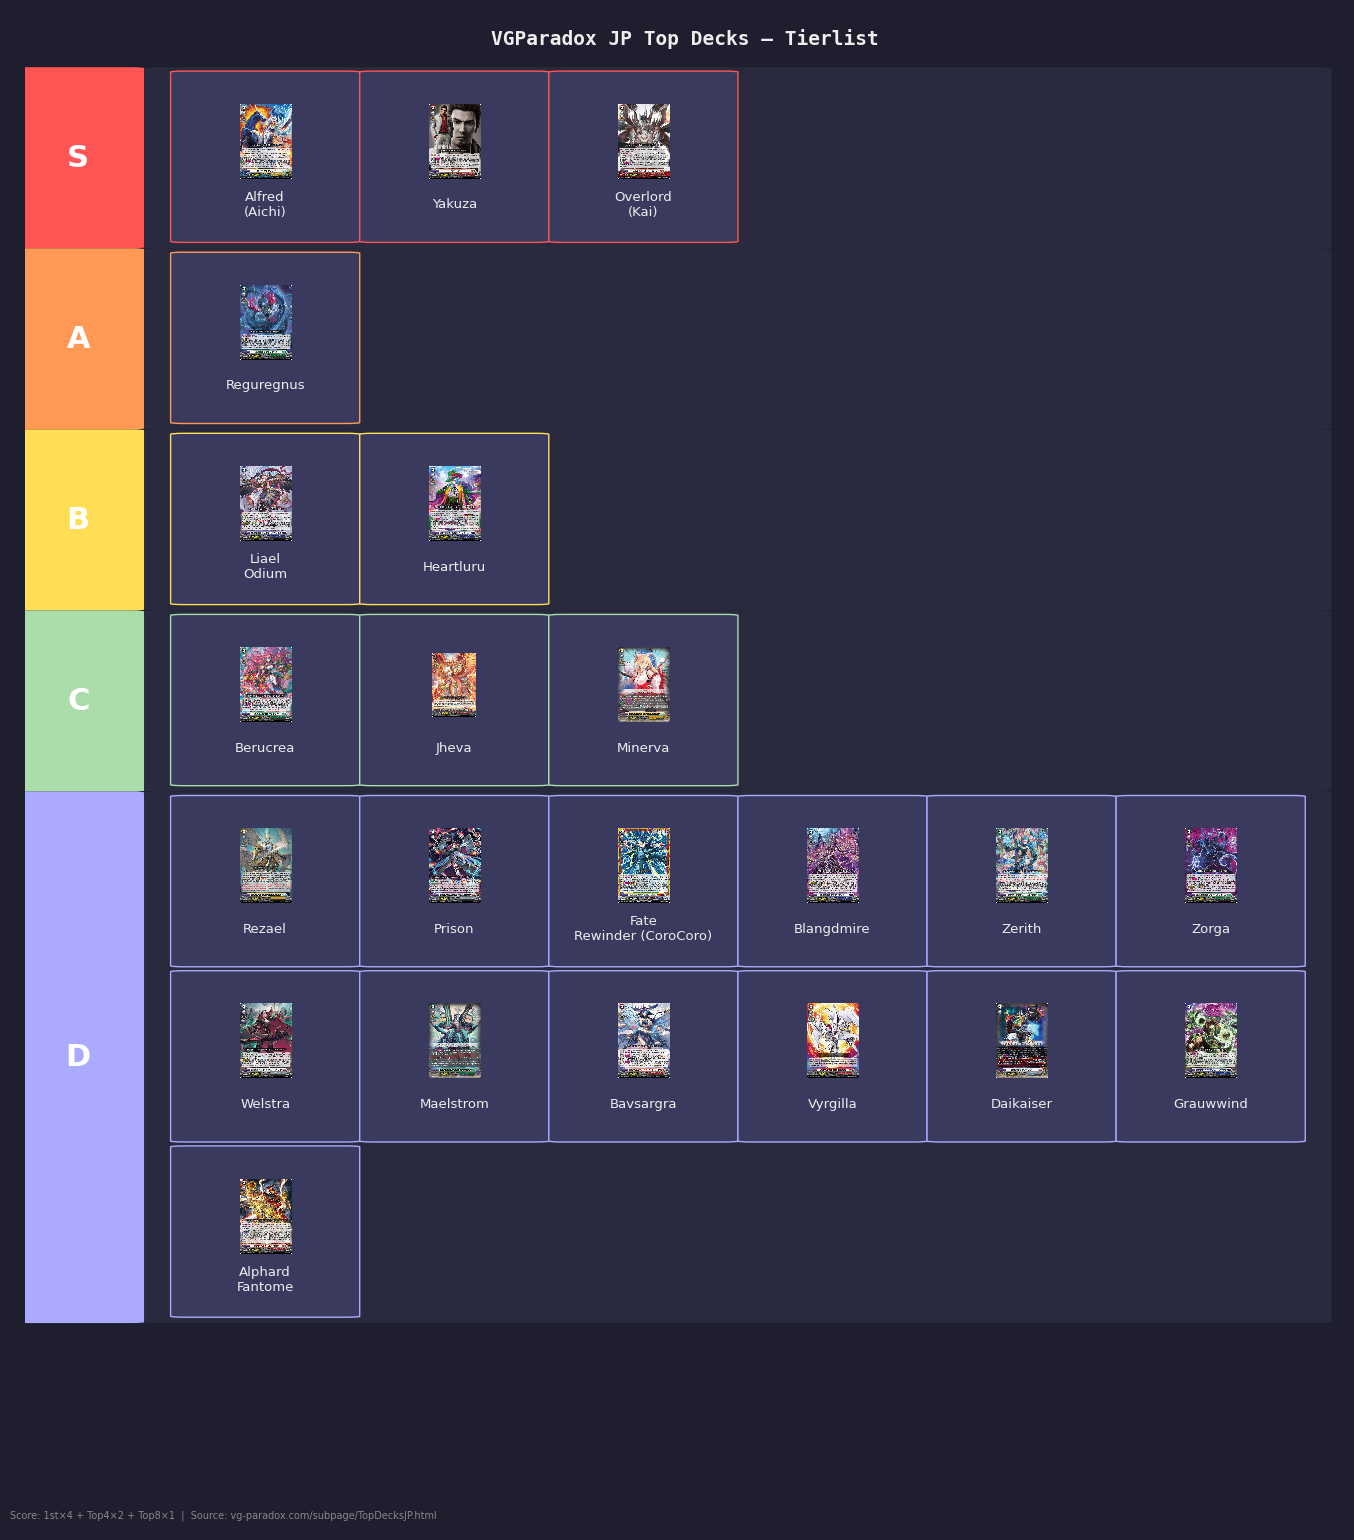

✅ Saved as tierlist_jp.png


In [91]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import to_rgba

TIER_COLORS = {
    'S': '#FF5555',
    'A': '#FF9955',
    'B': '#FFDD55',
    'C': '#AADDAA',
    'D': '#AAAAFF',
}
LABEL_BG   = '#1E1E2E'
ROW_BG     = '#2A2A3E'
CARD_BG    = '#3A3A5E'
TEXT_COLOR = '#EEEEEE'

tiers = ['S', 'A', 'B', 'C', 'D']
tier_data = {t: df[df['Tier'] == t]['Deck Name'].tolist() for t in tiers}
tier_data = {t: v for t, v in tier_data.items() if v}  # skip empty tiers

CARDS_PER_ROW = 6  # Changed from 5 to 6 to reduce card size
FIG_W = 14       # figure width in inches (must match figsize below)
LABEL_W = 0.08   # fraction of width for tier label column
PAD = 0.02

# Compute card dimensions for visual squares BEFORE calculating fig_h
# x: 1 data unit = FIG_W inches | y: 1 data unit = 1 inch
# For square cards: card_w * FIG_W == card_h * 1  →  card_h = card_w * FIG_W
card_area_w = 1 - LABEL_W - PAD * 3
card_w = card_area_w / CARDS_PER_ROW - PAD
card_h = card_w * FIG_W          # visually square
ROW_H  = card_h + PAD * 3        # row height = card height + breathing room

# Calculate figure height
fig_rows = sum(max(1, -(-len(v) // CARDS_PER_ROW)) for v in tier_data.values())
fig_h = max(4, fig_rows * ROW_H + len(tier_data) * 0.3 + 1.5)

fig, ax = plt.subplots(figsize=(14, fig_h))
ax.set_xlim(0, 1)
ax.set_ylim(0, fig_h)
ax.axis('off')
fig.patch.set_facecolor(LABEL_BG)
ax.set_facecolor(LABEL_BG)

y = fig_h - 0.6

# Title
ax.text(0.5, fig_h - 0.3, 'VGParadox JP Top Decks — Tierlist',
        ha='center', va='center', fontsize=14, fontweight='bold',
        color=TEXT_COLOR, fontfamily='monospace')

for tier in tiers:
    decks = tier_data.get(tier, [])
    if not decks:
        continue

    n_rows = max(1, -(-len(decks) // CARDS_PER_ROW))  # ceiling division
    row_height = n_rows * ROW_H + PAD * 2
    color = TIER_COLORS[tier]

    # Tier label box
    label_rect = mpatches.FancyBboxPatch(
        (0, y - row_height), LABEL_W, row_height,
        boxstyle='round,pad=0.01', linewidth=0,
        facecolor=color, zorder=2
    )
    ax.add_patch(label_rect)
    ax.text(LABEL_W / 2, y - row_height / 2, tier,
            ha='center', va='center', fontsize=22, fontweight='bold',
            color='white', zorder=3)

    # Row background
    row_rect = mpatches.FancyBboxPatch(
        (LABEL_W + PAD, y - row_height), 1 - LABEL_W - PAD * 2, row_height,
        boxstyle='round,pad=0.01', linewidth=0,
        facecolor=ROW_BG, zorder=2
    )
    ax.add_patch(row_rect)

    # Deck cards

    for i, deck in enumerate(decks):
        col = i % CARDS_PER_ROW
        row = i // CARDS_PER_ROW
        cx = LABEL_W + PAD * 2 + col * (card_w + PAD)
        cy = y - PAD - row * ROW_H - card_h / 2 - PAD

        card = mpatches.FancyBboxPatch(
            (cx, cy - card_h / 2), card_w, card_h,
            boxstyle='round,pad=0.01', linewidth=1,
            edgecolor=color, facecolor=CARD_BG, zorder=3
        )
        ax.add_patch(card)

        img_arr = images.get(deck)
        if img_arr is not None:
            # Scale image to fit inside the card, leaving room for the label
            # zoom is relative to figure pixels — tune IMAGE_ZOOM if images look too big/small
            IMAGE_ZOOM = 0.105
            oi = OffsetImage(img_arr, zoom=IMAGE_ZOOM, zorder=4)
            oi.image.axes = ax
            img_cy = cy + card_h * 0.09  # shift image slightly upward to leave label space
            ab = AnnotationBbox(
                oi, (cx + card_w / 2, img_cy),
                frameon=False, zorder=4,
                box_alignment=(0.5, 0.5)
            )
            ax.add_artist(ab)
            # Deck name label sits below the image
            label_cy = cy - card_h * 0.28
            fontsize = 9.5
        else:
            # No image — center the name in the card
            label_cy = cy
            fontsize = 9.5

        # Wrap long deck names
        words = deck.split()
        mid = len(words) // 2
        line1 = ' '.join(words[:mid]) if mid > 0 else deck
        line2 = ' '.join(words[mid:]) if mid > 0 else ''
        label = f"{line1}\n{line2}" if line2 else line1

        ax.text(cx + card_w / 2, label_cy, label,
                ha='center', va='center', fontsize=fontsize,
                color=TEXT_COLOR, zorder=4, multialignment='center')

    y -= row_height + PAD

# Footer
ax.text(0.15, 0.15,
        'Score: 1st×4 + Top4×2 + Top8×1  |  Source: vg-paradox.com/subpage/TopDecksJP.html',
        ha='center', va='center', fontsize=7, color='#888888')

plt.tight_layout()
plt.savefig('tierlist_jp.png', dpi=150, bbox_inches='tight', facecolor=LABEL_BG)
plt.show()
print('✅ Saved as tierlist_jp.png')